# DiaCompanion — Phân đoạn tổn thương DR trên TJDR (U-Net đa lớp)

Notebook huấn luyện **U-Net multi-class (5 lớp: 0=nền, 1=EX, 2=HE, 3=MA, 4=SE)** trên bộ **TJDR**
(Mao et al., 2023, arXiv:2312.15389), chạy trên **Google Colab (GPU T4)**.

**Tại sao chọn U-Net đa lớp thay vì framework Federated Learning gốc?**
TJDR-FL được thiết kế cho học liên kết phân tán (bảo mật dữ liệu) — nặng và thừa cho capstone.
U-Net đa lớp khớp đúng định dạng nhãn index-map 0–4 của TJDR, nhẹ, và là cách đã được kiểm chứng
trên TJDR/IDRiD/DDR.

> **Lưu ý y khoa:** đây là công cụ nghiên cứu/capstone, không thay thế chẩn đoán của bác sĩ nhãn khoa.

---
### Quy trình
1. Bật GPU → 2. Cài đặt → 3. Tải dataset → 4. Tự dò cấu trúc & kiểm tra nhãn →
5. Split theo ảnh (seed) → 6. Dataset/Augment → 7. Model → 8. Loss/Optim →
9. Train → 10. Đánh giá per-lesion → 11. Visualize → 12. Lưu model


## 0) Kiểm tra GPU
Runtime → Change runtime type → **T4 GPU** trước khi chạy.

In [1]:
!nvidia-smi -L
import torch
print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU 0: Tesla T4 (UUID: GPU-ca5ba336-c439-cb08-6fd4-aac073bdd6ad)
CUDA: True | Tesla T4


## 1) Cài thư viện

In [2]:
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.4.0
import segmentation_models_pytorch as smp, albumentations as A
print("smp", smp.__version__)

smp 0.3.4


## 2) Tải dataset TJDR

Repo Git thường chỉ chứa annotation/metadata; **ảnh gốc 561 tấm + mask tải qua link trong README**
của https://github.com/NekoPii/TJDR .

Có 3 cách đưa dữ liệu vào Colab — chọn 1:
- **A. Google Drive** (khuyên dùng): tải TJDR về Drive rồi mount.
- **B. Tải trực tiếp** bằng `gdown` nếu README cho link Google Drive.
- **C. Upload thủ công** qua panel Files.


In [3]:
# --- Cách A: Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')
# Sau khi mount, đặt biến trỏ tới thư mục TJDR trong Drive của bạn, ví dụ:
# DATA_ROOT = '/content/drive/MyDrive/TJDR'
DATA_ROOT = '/content/drive/MyDrive/TJDR'   # <-- SỬA cho đúng đường dẫn của bạn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# --- (tuỳ chọn) Cách B: tải bằng gdown nếu có FILE_ID từ link Google Drive trong README ---
# !pip install -q gdown
# import gdown
# gdown.download_folder('https://drive.google.com/drive/folders/<FILE_ID>', output='/content/TJDR', quiet=False)
# DATA_ROOT = '/content/TJDR'
print("DATA_ROOT =", DATA_ROOT)

DATA_ROOT = /content/drive/MyDrive/TJDR


## 3) Tự dò cấu trúc thư mục
TJDR có ảnh (`.jpg/.png`) và mask index (`.png`, giá trị 0–4). Tên thư mục có thể khác nhau,
ô dưới sẽ liệt kê để bạn xác định đúng `IMG_DIR` và `MASK_DIR`.

In [5]:
import os, glob
for r, d, f in os.walk(DATA_ROOT):
    exts = {}
    for name in f:
        e = os.path.splitext(name)[1].lower(); exts[e] = exts.get(e, 0) + 1
    if f:
        print(f"{r}  ->  {dict(exts)}  (vd: {f[0]})")

/content/drive/MyDrive/TJDR/train/image  ->  {'.png': 448}  (vd: TJDR_train_284.png)
/content/drive/MyDrive/TJDR/train/annotation  ->  {'.png': 448}  (vd: TJDR_train_385.png)
/content/drive/MyDrive/TJDR/test/annotation  ->  {'.png': 113}  (vd: TJDR_test_071.png)
/content/drive/MyDrive/TJDR/test/image  ->  {'.png': 113}  (vd: TJDR_test_031.png)


In [6]:
# SỬA hai đường dẫn này theo kết quả ô trên:
IMG_DIR  = os.path.join(DATA_ROOT, 'train/image')       # ảnh fundus
MASK_DIR = os.path.join(DATA_ROOT, 'train/annotation')  # mask tổn thương

img_files  = sorted(glob.glob(os.path.join(IMG_DIR,  '*')))
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, '*')))
print("Số ảnh:", len(img_files), "| Số mask:", len(mask_files))
assert len(img_files) > 0 and len(mask_files) > 0, "Chưa thấy file — kiểm tra lại IMG_DIR/MASK_DIR"


Số ảnh: 448 | Số mask: 448


### 3b) Ghép cặp ảnh–mask theo tên & KIỂM TRA giá trị nhãn
Bước kiểm tra cực kỳ quan trọng: mask **phải** mang giá trị nguyên 0–4.
Nếu in ra thấy `[0 255]` hoặc giá trị lớn → mask đang ở dạng khác (nhị phân/RGB) và cần xử lý lại,
KHÔNG được nhân/chia 255 lên mask (tránh lỗi double-normalization).

In [7]:
import cv2, numpy as np

def stem(p): return os.path.splitext(os.path.basename(p))[0]
mask_by_stem = {stem(m): m for m in mask_files}

pairs = [(ip, mask_by_stem[stem(ip)]) for ip in img_files if stem(ip) in mask_by_stem]
print("Số cặp ghép được:", len(pairs))
assert len(pairs) > 0, "Tên ảnh và mask không khớp — kiểm tra quy tắc đặt tên"

# Kiểm tra giá trị nhãn gốc
vals=set()
for _, mp in pairs[:20]:
    m=cv2.imread(mp,cv2.IMREAD_GRAYSCALE)
    vals|=set(np.unique(m).tolist())
print("Giá trị nhãn gốc:",sorted(vals))

# Remap về 0–4
GRAY2CLS={0:0,14:1,38:2,75:3,113:4}
def load_mask(mp):
    raw=cv2.imread(mp,cv2.IMREAD_UNCHANGED)
    if raw.ndim==3: raw=cv2.cvtColor(raw,cv2.COLOR_BGR2GRAY)
    out=np.zeros(raw.shape,np.uint8)
    for g,c in GRAY2CLS.items(): out[raw==g]=c
    return out

# Kiểm tra toàn bộ sau remap
seen=set()
for _,mp in pairs:
    seen|=set(np.unique(load_mask(mp)).tolist())
print("Giá trị sau remap:",sorted(seen))
assert seen.issubset({0,1,2,3,4}), "Còn nhãn ngoài 0–4"


Số cặp ghép được: 448
Giá trị nhãn gốc: [0, 14, 38, 75, 113]
Giá trị sau remap: [0, 2, 3, 4]


## 4) Split theo ảnh (có seed để tái lập)
Ghi seed + danh sách test vào báo cáo để tái lập.

In [8]:
import random
SEED=42
random.seed(SEED); random.shuffle(pairs)
n=len(pairs); n_tr=int(0.7*n); n_va=int(0.15*n)
train_pairs=pairs[:n_tr]; val_pairs=pairs[n_tr:n_tr+n_va]; test_pairs=pairs[n_tr+n_va:]
print(f"Train {len(train_pairs)} | Val {len(val_pairs)} | Test {len(test_pairs)} (seed={SEED})")

# Lưu danh sách test để tái lập
with open('test_files.txt','w') as f:
    for ip,_ in test_pairs: f.write(os.path.basename(ip)+'\n')
print("Đã lưu test_files.txt")


Train 313 | Val 67 | Test 68 (seed=42)
Đã lưu test_files.txt


## 5) Dataset + Augmentation
Mask giữ nguyên 0–4 (không normalize mask). Ảnh chuẩn hoá theo thống kê ImageNet.

In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

SIZE, NUM_CLASSES, BATCH = 512, 5, 4
MEAN, STD = (0.485,0.456,0.406), (0.229,0.224,0.225)

train_tf=A.Compose([
    A.Resize(SIZE,SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=MEAN,std=STD), ToTensorV2()
])
val_tf=A.Compose([A.Resize(SIZE,SIZE), A.Normalize(mean=MEAN,std=STD), ToTensorV2()])

class TJDRDataset(Dataset):
    def __init__(self,pairs,tf): self.pairs,self.tf=pairs,tf
    def __len__(self): return len(self.pairs)
    def __getitem__(self,i):
        ip,mp=self.pairs[i]
        img=cv2.cvtColor(cv2.imread(ip),cv2.COLOR_BGR2RGB)
        a=self.tf(image=img,mask=load_mask(mp))   # dùng load_mask đã remap
        return a['image'],a['mask'].long()

train_dl=DataLoader(TJDRDataset(train_pairs,train_tf),batch_size=BATCH,shuffle=True,num_workers=2,pin_memory=True)
val_dl=DataLoader(TJDRDataset(val_pairs,val_tf),batch_size=BATCH,shuffle=False,num_workers=2,pin_memory=True)
test_dl=DataLoader(TJDRDataset(test_pairs,val_tf),batch_size=1,shuffle=False,num_workers=2,pin_memory=True)

# Kiểm tra nhanh
xb,yb=next(iter(train_dl))
print("Ảnh:",xb.shape,"| Nhãn unique:",torch.unique(yb).tolist())


Ảnh: torch.Size([4, 3, 512, 512]) | Nhãn unique: [0, 2, 3, 4]


## 6) Model — U-Net (encoder ResNet34 pretrained ImageNet), 5 lớp

In [10]:
import segmentation_models_pytorch as smp
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                 in_channels=3, classes=NUM_CLASSES).to(device)
print("Tham số:", sum(p.numel() for p in model.parameters())/1e6, "triệu")

Tham số: 24.436949 triệu


## 7) Loss + Optimizer
Tổn thương rất nhỏ, nền chiếm >99% pixel → mất cân bằng nặng. Dùng **Dice + CrossEntropy**.

In [11]:
dice_loss = smp.losses.DiceLoss(mode='multiclass')
ce_loss   = torch.nn.CrossEntropyLoss()
def criterion(logits, y): return dice_loss(logits, y) + ce_loss(logits, y)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_21499/89170958.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## 8) Hàm đánh giá Dice/IoU **theo từng loại tổn thương**
Báo cáo riêng EX/HE/MA/SE — MA thường thấp nhất vì rất nhỏ.

In [12]:
LESION = {1:'EX',2:'HE',3:'MA',4:'SE'}

@torch.no_grad()
def evaluate(dl):
    model.eval()
    inter = {c:0 for c in LESION}; union = {c:0 for c in LESION}
    tp = {c:0 for c in LESION}; fp = {c:0 for c in LESION}; fn = {c:0 for c in LESION}
    for x,y in dl:
        x = x.to(device); y = y.to(device)
        pred = model(x).argmax(1)
        for c in LESION:
            p = (pred==c); t = (y==c)
            inter[c]+= (p&t).sum().item(); union[c]+= (p|t).sum().item()
            tp[c]+=(p&t).sum().item(); fp[c]+=(p&~t).sum().item(); fn[c]+=(~p&t).sum().item()
    rows={}
    for c in LESION:
        iou = inter[c]/union[c] if union[c]>0 else float('nan')
        dice= 2*tp[c]/(2*tp[c]+fp[c]+fn[c]) if (2*tp[c]+fp[c]+fn[c])>0 else float('nan')
        rows[LESION[c]] = (dice, iou)
    return rows

def fmt(rows):
    return " | ".join([f"{k}: Dice={v[0]:.3f} IoU={v[1]:.3f}" for k,v in rows.items()])

## 9) Vòng huấn luyện (lưu model tốt nhất theo Dice trung bình val)

In [13]:
import numpy as np
EPOCHS = 40
best = -1
for ep in range(1, EPOCHS+1):
    model.train(); run=0
    for x,y in train_dl:
        x=x.to(device); y=y.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model(x); loss = criterion(logits,y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        run += loss.item()
    rows = evaluate(val_dl)
    mdice = np.nanmean([v[0] for v in rows.values()])
    print(f"Epoch {ep:02d} | loss {run/len(train_dl):.4f} | val mDice {mdice:.3f} | {fmt(rows)}")
    if mdice > best:
        best = mdice; torch.save(model.state_dict(), 'tjdr_unet_best.pth')
        print(f"  -> lưu model tốt nhất (mDice={best:.3f})")

Epoch 01 | loss 1.8112 | val mDice 0.003 | EX: Dice=0.000 IoU=0.000 | HE: Dice=0.012 IoU=0.006 | MA: Dice=0.000 IoU=0.000 | SE: Dice=0.000 IoU=0.000
  -> lưu model tốt nhất (mDice=0.003)
Epoch 02 | loss 1.1248 | val mDice 0.000 | EX: Dice=0.000 IoU=0.000 | HE: Dice=0.000 IoU=0.000 | MA: Dice=0.000 IoU=0.000 | SE: Dice=0.000 IoU=0.000
Epoch 03 | loss 0.9398 | val mDice 0.000 | EX: Dice=0.000 IoU=0.000 | HE: Dice=0.000 IoU=0.000 | MA: Dice=0.000 IoU=0.000 | SE: Dice=0.000 IoU=0.000
Epoch 04 | loss 0.8185 | val mDice 0.000 | EX: Dice=0.000 IoU=0.000 | HE: Dice=0.000 IoU=0.000 | MA: Dice=0.000 IoU=0.000 | SE: Dice=0.000 IoU=0.000
Epoch 05 | loss 0.7410 | val mDice 0.000 | EX: Dice=0.000 IoU=0.000 | HE: Dice=0.000 IoU=0.000 | MA: Dice=0.000 IoU=0.000 | SE: Dice=0.000 IoU=0.000
Epoch 06 | loss 0.6860 | val mDice 0.000 | EX: Dice=0.000 IoU=0.000 | HE: Dice=0.000 IoU=0.000 | MA: Dice=0.000 IoU=0.000 | SE: Dice=0.000 IoU=0.000
Epoch 07 | loss 0.6429 | val mDice 0.000 | EX: Dice=nan IoU=nan | HE

## 10) Đánh giá trên tập test

In [14]:
model.load_state_dict(torch.load('tjdr_unet_best.pth'))
rows = evaluate(test_dl)
print("KẾT QUẢ TEST (per-lesion):")
print(fmt(rows))
print("Tham chiếu TJDR/IDRiD (state-of-the-art): IoU ~0.66, F1 ~0.79 — dùng làm mốc kỳ vọng.")

KẾT QUẢ TEST (per-lesion):
EX: Dice=nan IoU=nan | HE: Dice=0.496 IoU=0.330 | MA: Dice=0.613 IoU=0.442 | SE: Dice=0.104 IoU=0.055
Tham chiếu TJDR/IDRiD (state-of-the-art): IoU ~0.66, F1 ~0.79 — dùng làm mốc kỳ vọng.


## 11) Visualize vài dự đoán

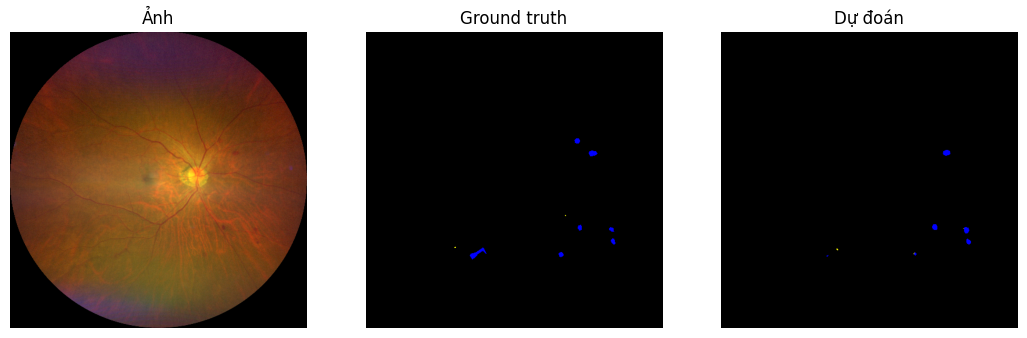

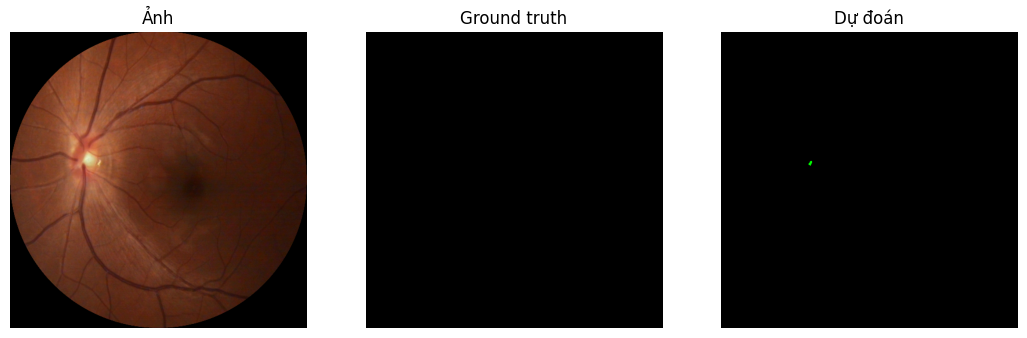

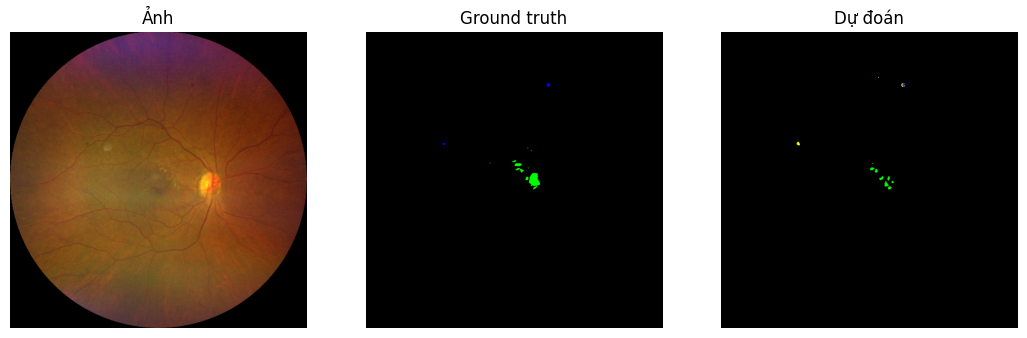

Màu: đỏ=EX, lục=HE, lam=MA, vàng=SE


In [15]:
import matplotlib.pyplot as plt
COLORS = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0]], np.uint8)  # 0..4
def colorize(m): return COLORS[m]

model.eval()
shown=0
with torch.no_grad():
    for x,y in test_dl:
        pred = model(x.to(device)).argmax(1)[0].cpu().numpy()
        img = (x[0].permute(1,2,0).numpy()*np.array(STD)+np.array(MEAN)).clip(0,1)
        gt  = y[0].numpy()
        fig,ax=plt.subplots(1,3,figsize=(13,4))
        ax[0].imshow(img); ax[0].set_title('Ảnh'); ax[0].axis('off')
        ax[1].imshow(colorize(gt)); ax[1].set_title('Ground truth'); ax[1].axis('off')
        ax[2].imshow(colorize(pred)); ax[2].set_title('Dự đoán'); ax[2].axis('off')
        plt.show(); shown+=1
        if shown>=3: break
print("Màu: đỏ=EX, lục=HE, lam=MA, vàng=SE")

## 12) Lưu model về Drive
```python
import shutil; shutil.copy('tjdr_unet_best.pth', '/content/drive/MyDrive/tjdr_unet_best.pth')
```

---
### Trích dẫn
- Mao J., Ma X., Bi Y., Zhang R. (2023). *TJDR: A High-Quality Diabetic Retinopathy Pixel-Level Annotation Dataset.* arXiv:2312.15389.
- Mao J. et al. (2024). *A Comprehensive Federated Learning Framework for DR Grading and Lesion Segmentation.* IEEE Transactions on Big Data.

### Ghi vào báo cáo (bắt buộc, để tái lập)
- Seed split = 42; tỉ lệ 70/15/15 theo ảnh; danh sách test trong `test_files.txt`.
- Kích thước ảnh: 512×512; encoder ResNet34 (ImageNet); loss Dice+CE; AdamW lr=1e-4.
- Báo cáo Dice/IoU **theo từng loại tổn thương**; nêu rõ MA khó nhất do kích thước nhỏ.
